# Stage 12 — Mars threshold and prediction analysis

_Pipeline stage 12 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Threshold sensitivity — the scientific knob on label-free Mars

Mars has no ground truth, so the coupling *rate* depends on the chosen decision
threshold. A trustworthy conclusion is one that is **stable** across a sensible
threshold band and **consistent** across regimes — not an artifact of one cut. We sweep
the threshold for both the headline rate and the high-confidence rate.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


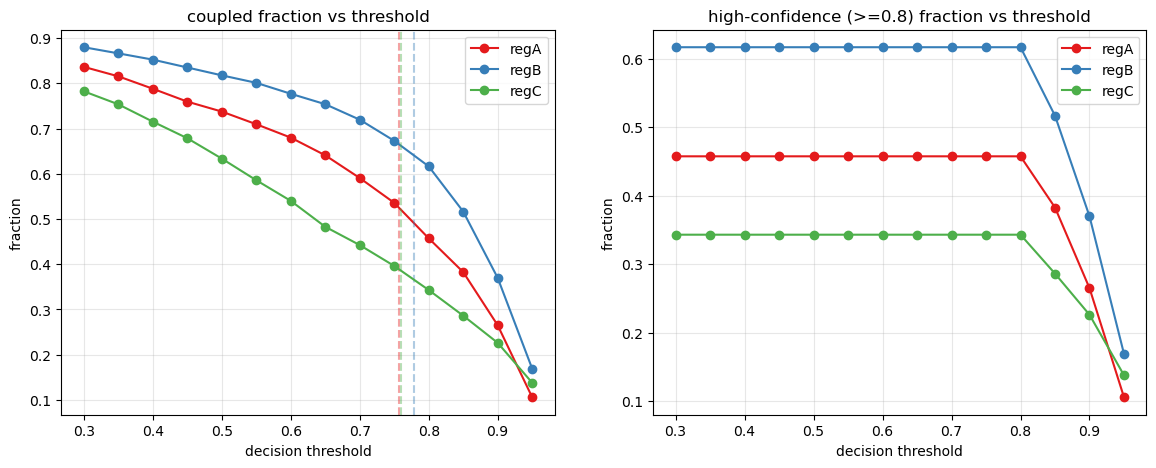

In [2]:
SWEEP = np.round(np.arange(0.30, 0.96, 0.05), 2)
P = {r: pd.read_parquet(MARS_OUT / f'mars_combined_{r}_predictions.parquet').prob_touching.to_numpy()
     for r in REGIMES_ if (MARS_OUT / f'mars_combined_{r}_predictions.parquet').exists()}
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for r, pr in P.items():
    ax[0].plot(SWEEP, [(pr >= t).mean() for t in SWEEP], 'o-', color=RC[r], label=r)
    ax[0].axvline(OP_THR[r], color=RC[r], ls='--', alpha=0.4)
    ax[1].plot(SWEEP, [((pr >= t) & (pr >= 0.8)).mean() for t in SWEEP], 'o-', color=RC[r], label=r)
ax[0].set_title('coupled fraction vs threshold'); ax[1].set_title('high-confidence (>=0.8) fraction vs threshold')
for a in ax: a.set_xlabel('decision threshold'); a.set_ylabel('fraction'); a.legend(); a.grid(alpha=0.3)
plt.show()

In [3]:
# Operating-point summary table.
pd.DataFrame([{'regime': r, 'operating_threshold': OP_THR[r],
               'coupled_%': round(100*(P[r] >= OP_THR[r]).mean(), 1),
               'high_conf_%': round(100*(P[r] >= 0.8).mean(), 1)} for r in P])

,regime,operating_threshold,coupled_%,high_conf_%
0,regA,0.756326,53.0,45.7
1,regB,0.779264,64.1,61.7
2,regC,0.759369,38.6,34.3


**Takeaway.** The curves are **smooth** through the operating band (no cliff), so the
coupled fraction is a stable estimate rather than a threshold artifact. Crucially the
regime **ordering is invariant** — regB > regA > regC at *every* threshold — so the
qualitative conclusion (coupling is common, and scales with network density as
expected) does not depend on the exact cut. This is what lets us report a result
despite Mars having no labels.